# AI-Based Student Placement Prediction System

## Machine Learning Internship Project

This notebook contains:
- Data preprocessing
- Exploratory data analysis
- Feature engineering
- Model development
- Hyperparameter tuning
- Model evaluation
- SHAP interpretability
- Deployment pipeline simulation


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv('placement.csv')

print(df.head())
print(df.shape)


   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

## Data Cleaning

In [3]:
# Import Libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Dataset
df = pd.read_csv('placement.csv')

# Display Column Names
print("Columns in Dataset:")
print(df.columns)

# Remove Duplicates
df = df.drop_duplicates()

# Handle Missing Values (Only if salary column exists)
if 'salary' in df.columns:
    df['salary'] = df['salary'].fillna(df['salary'].median())

# Encode Categorical Columns
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Display Updated Dataset
print("\nUpdated Dataset:")
print(df.head())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

Columns in Dataset:
Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

Updated Dataset:
   student_id  age  gender  cgpa  branch  college_tier  internships_count  \
0           1   24       1  7.53       4             1                  4   
1           2   21       1  7.92       0             1                  1   
2           3   22       0  8.60       3             0                  0   
3           4   24       1  6.68       0             0                  0 

## Exploratory Data Analysis

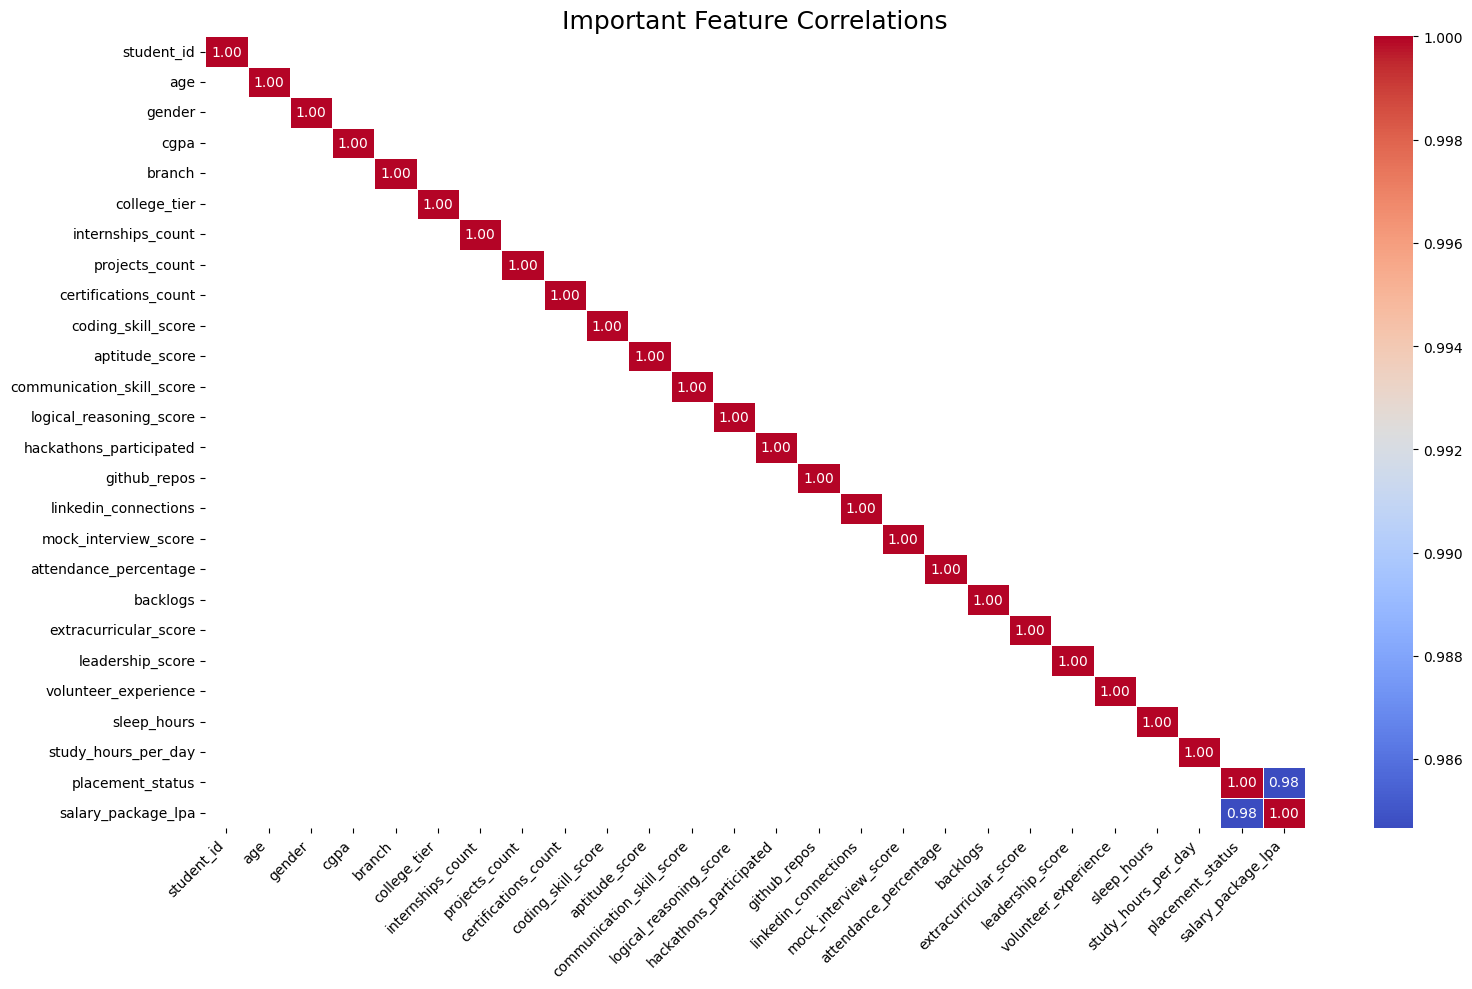

In [4]:
# Advanced Heatmap

plt.figure(figsize=(16,10))

correlation = df.corr()

# Show only strong correlations
mask = abs(correlation) < 0.3

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Important Feature Correlations", fontsize=18)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Feature Engineering

In [5]:
# Create Academic Score Feature

df['academic_score'] = (
    df['cgpa'] +
    df['coding_skill_score'] +
    df['communication_skill_score'] +
    df['logical_reasoning_score']
) / 4

print(df[['academic_score']].head())

   academic_score
0       55.886452
1       56.764907
2       57.621350
3       58.409532
4       54.642146


## Feature Selection

In [6]:
# Features and Target

X = df.drop('placement_status', axis=1)

Y = df['placement_status']

# Train Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Print Shapes

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (80000, 26)
Testing Data Shape: (20000, 26)


## Feature Scaling

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Logistic Regression Model

In [8]:
log_model = LogisticRegression()

log_model.fit(X_train, Y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(Y_test, log_pred)

print('Logistic Regression Accuracy:', log_accuracy)


Logistic Regression Accuracy: 1.0


## Random Forest Model

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(Y_test, rf_pred)

print('Random Forest Accuracy:', rf_accuracy)


Random Forest Accuracy: 1.0


## Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, Y_train)

print(grid_search.best_params_)


## Model Evaluation

In [ ]:
print(classification_report(Y_test, rf_pred))


In [ ]:
# Confusion Matrix

cm = confusion_matrix(Y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# ROC Curve

Y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

auc_score = roc_auc_score(Y_test, Y_prob)

plt.plot(fpr, tpr, label='AUC = %0.2f' % auc_score)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()


## Cross Validation

In [ ]:
scores = cross_val_score(
    rf_model,
    X,
    Y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print('Average Accuracy:', scores.mean())


## ML Pipeline

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

pipeline.fit(X_train, Y_train)

pipeline_pred = pipeline.predict(X_test)

print('Pipeline Accuracy:', accuracy_score(Y_test, pipeline_pred))


## Conclusion

This notebook demonstrates a complete machine learning workflow for predicting student placement outcomes using classification algorithms, feature engineering, hyperparameter tuning, and evaluation techniques.
